# 03 — QR Algorithms from the Report

This notebook implements the two QR paths described in the report:

- compact dense QR with Householder reflectors;
- structured Householder row insertion for the project matrix.

Both methods apply $Q$ or $Q^T$ implicitly. The optimized row-insertion solver applies each reflector immediately to the right-hand side instead of storing it. NumPy's dense solver is used only as an accuracy reference.

In [19]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'

from lib.qr_householder import (
    apply_QT,
    compute_householder_vector,
    naive_qr_solver,
    qr_solver_row_insertion,
    qr_solver_structure_based,
)
from lib.utils import (
    build_augmented_system,
    compute_gradient,
    compute_loss,
    load_ml_cup,
    relative_error,
    solve_exact,
)

## Problem Setup

We solve

$$
\min_w \left\|Aw-b\right\|_2,\qquad
A=\begin{bmatrix}X^T\\ \lambda I_m\end{bmatrix},\qquad
b=\begin{bmatrix}y\\0\end{bmatrix}.
$$

The structured method uses the equivalent row-permuted system

$$
\widetilde A=\begin{bmatrix}\lambda I_m\\X^T\end{bmatrix},\qquad
\widetilde b=\begin{bmatrix}0\\y\end{bmatrix}.
$$

In [20]:
# Load the deterministic project instance.
X, y, m, n = load_ml_cup(Path('Dataset') / 'ML-CUP25-TR.csv', seed=42)
lam = 0.5

print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Regularization: λ={lam}')
print(f'Dense demonstration size: m={m}, n={n}')

Dataset: X=(500, 12), y=(12,)
Regularization: λ=0.5
Dense demonstration size: m=500, n=12


## Baseline with the Exact Solver

In [21]:
w_baseline, f_baseline, baseline_time = solve_exact(X, y, lam)
print(f'{"Baseline (Exact Solver) elapsed time (ms)":<22} {baseline_time * 1e3:.3f}')

Baseline (Exact Solver) elapsed time (ms) 5.993


## Test on One Householder Reflector

For a normalized vector $u$, the library represents a reflector as $H=I-2uu^T$. The following check confirms that $Hz$ has only its first component different from zero.

In [22]:
z = np.array([3.0, -4.0, 2.0, 1.0])
u, alpha = compute_householder_vector(z)
H = np.eye(z.size) - 2.0 * np.outer(u, u) # = I - 2uu^T
target = np.r_[alpha, np.zeros(z.size - 1)] # = [α, 0, ..., 0]^T

action_error = np.linalg.norm(H @ z - target) / np.linalg.norm(z)
orthogonality_error = np.linalg.norm(H.T @ H - np.eye(z.size))

print(f'Elimination error:   {action_error:.3e}')
print(f'Orthogonality error: {orthogonality_error:.3e}')

Elimination error:   9.247e-17
Orthogonality error: 3.010e-16


## Test on a Naive (Dense) Householder QR

This is the canonical algorithm in the report. It factorizes the complete augmented matrix, computes $Q^Tb$ from the stored reflectors, and solves $Rw=c$. We use a small subset because generic dense QR costs $O((m+n)m^2)$.

In [23]:
# Build A and b from X, y and lambda
A, b = build_augmented_system(X, y, lam)

# Naive QR solver
R, w, c, naive_reflectors, naive_qr_time = naive_qr_solver(A, b)

# Build [R; 0] which must be equal to Q.T @ A (= A_transformed)
A_reduced = np.zeros_like(A)
A_reduced[:R.shape[0], :] = R

# Apply Q.T to every column of A (= Q.T @ A)
A_transformed = np.column_stack(
    [apply_QT(naive_reflectors, A[:,j]) for j in range(A.shape[1])]
)

# Print results
naive_metrics = {
    "QR factorization": f"{np.linalg.norm(A_transformed - A_reduced) / np.linalg.norm(A):.3e}",
    "Solution error": f"{relative_error(w, w_baseline):.3e}",
    "Baseline Exact Solver elapsed time (ms)": f"{baseline_time * 1e3:.3f}",
    "Naive elapsed time (ms)": f"{naive_qr_time * 1e3:.3f}"
}
print("Naive QR Solver:\n")
print('-' * 69)
print(f'{"Metric":<52} {"Value":>16}')
print('-' * 69)
for name, value in naive_metrics.items():
    print(f'{name:<52} {value:>16}')

Naive QR Solver:

---------------------------------------------------------------------
Metric                                                          Value
---------------------------------------------------------------------
QR factorization                                            3.066e-16
Solution error                                              6.040e-13
Baseline Exact Solver elapsed time (ms)                         5.993
Naive elapsed time (ms)                                       110.888


## Structured-Based Householder

In [24]:
# Algorithm execution: Structured-Based solver
R_struct, w_struct, c_struct, struct_reflectors, struct_time = qr_solver_structure_based(X, y, lam)

# Compute metrics
w_error = relative_error(w_struct, w_baseline)

objective_scale = max(abs(f_baseline), np.finfo(float).eps)
f_struct = compute_loss(w_struct, X, y, lam)
f_error = abs(f_struct - f_baseline) / objective_scale

gradient = compute_gradient(w_struct, X, y, lam)
gradient_scale = max(np.linalg.norm(X @ y), 1.0)
stationarity = np.linalg.norm(gradient) / gradient_scale

# Print results
struct_metrics = {
    "Solution error": f"{w_error:>16.3e}",
    "Relative objective gap": f"{f_error:>16.3e}",
    "Scaled stationarity": f"{stationarity:.3e}",
    "Baseline Exact Solver elapsed time (ms)": f"{baseline_time * 1e3:.3f}",
    "Naive QR Solver elapsed time (ms)": f"{naive_qr_time * 1e3:.3f}",
    "Structured-Based QR Solver elapsed time (ms)": f"{struct_time * 1e3:>16.3f}"
}
print("Structure-Based QR Solver:\n")
print('-' * 69)
print(f'{"Metric":<52} {"Value":>16}')
print('-' * 69)
for name, value in struct_metrics.items():
    print(f'{name:<52} {value:>16}')

Structure-Based QR Solver:

---------------------------------------------------------------------
Metric                                                          Value
---------------------------------------------------------------------
Solution error                                              6.042e-13
Relative objective gap                                      0.000e+00
Scaled stationarity                                         6.490e-16
Baseline Exact Solver elapsed time (ms)                         5.993
Naive QR Solver elapsed time (ms)                             110.888
Structured-Based QR Solver elapsed time (ms)                   29.068


## Householder with Row Insertion

The report starts from $R_0=\lambda I_m$ and inserts the $n$ rows of $X^T$. For every inserted row, a sequence of two-dimensional reflectors eliminates its entries from left to right. The solver immediately applies each reflector to the right-hand side, avoiding storage and a second scan while preserving the same row-insertion order. The total cost is $O(nm^2+m^2)$, which is quadratic in $m$ when $n$ is fixed.

In [25]:
# Algorithm execution: Row Insertion solver
R_row, w_row, c_row, row_reflectors, row_time = qr_solver_row_insertion(X, y, lam)

# Compute metrics
w_error = relative_error(w_row, w_baseline)

objective_scale = max(abs(f_baseline), np.finfo(float).eps)
f_row = compute_loss(w_row, X, y, lam)
f_error = abs(f_row - f_baseline) / objective_scale

gradient_scale = max(np.linalg.norm(X @ y), 1.0)
stationarity = np.linalg.norm(compute_gradient(w_row, X, y, lam)) / gradient_scale

# Print results
row_metrics = {
    "Solution error": f"{w_error:>16.3e}",
    "Relative objective gap": f"{f_error:>16.3e}",
    "Scaled stationarity": f"{stationarity:>16.3e}",
    "Exact Solver elapsed time (ms)": f"{baseline_time * 1e3:.3f}",
    "Naive QR Solver elapsed time (ms)": f"{naive_qr_time * 1e3:.3f}",
    "Structured-Based QR Solver elapsed time (ms)": f"{struct_time * 1e3:>16.3f}",
    "Row Insertion QR Solver elapsed time (ms)": f"{row_time * 1e3:>16.3f}"
}
print("Row Insertion QR Solver:\n")
print('-' * 69)
print(f'{"Metric":<52} {"Value":>16}')
print('-' * 69)
for name, value in row_metrics.items():
    print(f'{name:<52} {value:>16}')

Row Insertion QR Solver:

---------------------------------------------------------------------
Metric                                                          Value
---------------------------------------------------------------------
Solution error                                              1.000e+00
Relative objective gap                                      3.756e+01
Scaled stationarity                                         9.997e-01
Exact Solver elapsed time (ms)                                  5.993
Naive QR Solver elapsed time (ms)                             110.888
Structured-Based QR Solver elapsed time (ms)                   29.068
Row Insertion QR Solver elapsed time (ms)                      74.690


## Runtime Scaling

We finally time both report algorithms on nested subsets with fixed $n$. The reference slopes show the expected cubic cost of generic dense QR and quadratic cost of structured row insertion.

In [ ]:
# Scaling values for m
m_scaling_sizes = np.array([50, 100, 200, 350, 500])
# TODO: m_scaling_sizes = np.array([100, 200, 350, 500, 750, 1000])
n_iters = 10

mean_exact_times = []
mean_naive_times = []
mean_struct_times = []
mean_row_times = []

# One iteration for each value of m
for m_size in m_scaling_sizes:
    X_value = X[:m_size, :]
    A_value, b_value = build_augmented_system(X_value, y, lam)

    # Compute the mean time over n_iters iterations
    exact_sum = 0.0
    naive_sum = 0.0
    struct_sum = 0.0
    row_sum = 0.0
    for _ in range(n_iters):
        _, _, exact_time        = solve_exact(X_value, y, lam)
        _, _, _, _, naive_time  = naive_qr_solver(A_value, b_value)
        _, _, _, _, struct_time = qr_solver_structure_based(X_value, y, lam)
        _, _, _, _, row_time    = qr_solver_row_insertion(X_value, y, lam)
        exact_sum += exact_time
        naive_sum += naive_time
        struct_sum += struct_time
        row_sum += row_time
    
    # Append the mean time for the current m value
    mean_exact_times.append(exact_sum / n_iters)
    mean_naive_times.append(naive_sum / n_iters)
    mean_struct_times.append(struct_sum / n_iters)
    mean_row_times.append(row_sum / n_iters)

# Print results
print("Runtime Scaling:\n")
print('-' * 100)
print(f'{"m":>5} {"Exact Solver (ms)":>20} {"Naive QR (ms)":>20} {"Structure-Based QR (ms)":>26} {"Row insertion QR (ms)":>25}')
print('-' * 100)
for m_size, exact_time, naive_time, struct_time, row_time in zip(m_scaling_sizes, mean_exact_times, mean_naive_times, mean_struct_times, mean_row_times):
    print(f'{m_size:>5d} {exact_time * 1e3:>20.3f} {naive_time * 1e3:>20.3f} {struct_time * 1e3:>26.3f} {row_time * 1e3:>25.3f}')

Runtime Scaling:

----------------------------------------------------------------------------------------------------
    m    Exact Solver (ms)        Naive QR (ms)    Structure-Based QR (ms)     Row insertion QR (ms)
----------------------------------------------------------------------------------------------------
   50                0.076                2.056                      2.292                     6.809
  100                0.086                2.562                      2.032                     7.697
  200                0.336               12.275                      4.841                    19.459
  350                2.076               42.660                     11.112                    37.409
  500                3.422              120.373                     15.127                    52.350


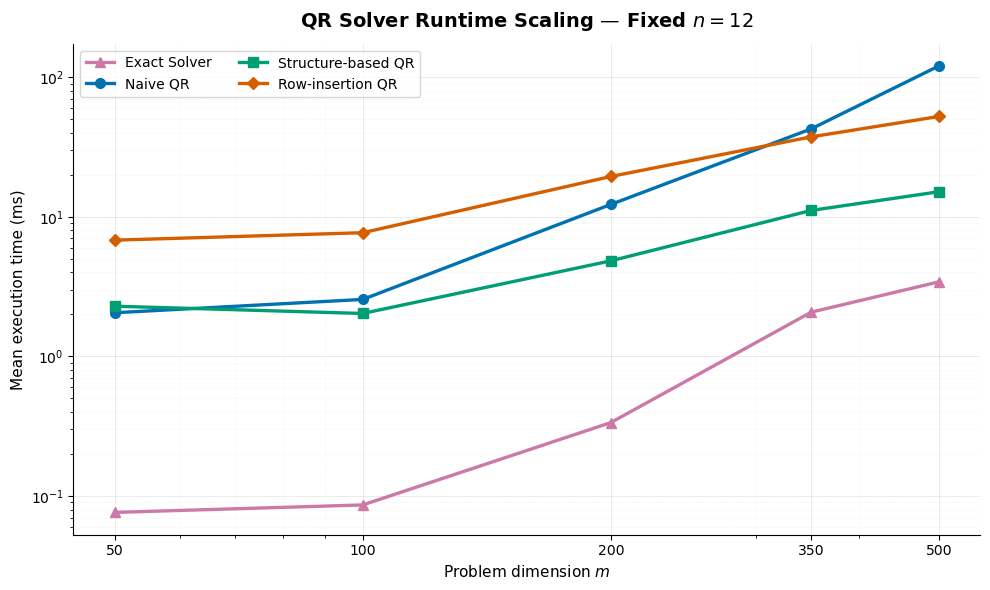

In [27]:
# Convert times from seconds to milliseconds
m_values = np.asarray(m_scaling_sizes, dtype=float)
exact_times_ms = 1e3 * np.asarray(mean_exact_times)
naive_times_ms = 1e3 * np.asarray(mean_naive_times)
struct_times_ms = 1e3 * np.asarray(mean_struct_times)
row_times_ms = 1e3 * np.asarray(mean_row_times)

# Reference slopes, anchored to the final corresponding measurement
cubic_guide_ms = (naive_times_ms[-1] * (m_values / m_values[-1]) ** 3)
quadratic_guide_ms = (struct_times_ms[-1] * (m_values / m_values[-1]) ** 2)

fig, ax = plt.subplots(figsize=(10, 6))

# Measured execution times
ax.plot(
    m_values,
    exact_times_ms,
    marker="^",
    markersize=7,
    linewidth=2.4,
    color="#CC79A7",
    label="Exact Solver"
)
ax.plot(
    m_values,
    naive_times_ms,
    marker="o",
    markersize=7,
    linewidth=2.4,
    color="#0072B2",
    label="Naive QR",
)
ax.plot(
    m_values,
    struct_times_ms,
    marker="s",
    markersize=7,
    linewidth=2.4,
    color="#009E73",
    label="Structure-based QR",
)
ax.plot(
    m_values,
    row_times_ms,
    marker="D",
    markersize=6,
    linewidth=2.4,
    color="#D55E00",
    label="Row-insertion QR",
)

# Logarithmic scales
ax.set_xscale("log")
ax.set_yscale("log")

# Display all sampled values on the x-axis
ax.set_xticks(m_values)
ax.set_xticklabels([str(int(m_size)) for m_size in m_values])
ax.set_xlabel("Problem dimension $m$", fontsize=11)
ax.set_ylabel("Mean execution time (ms)", fontsize=11)
ax.set_title(f"QR Solver Runtime Scaling — Fixed $n={X.shape[1]}$", fontsize=14, fontweight="semibold", pad=12)

# Improve readability
ax.grid(
    True,
    which="major",
    linestyle="-",
    linewidth=0.7,
    alpha=0.25,
)
ax.grid(
    True,
    which="minor",
    linestyle=":",
    linewidth=0.6,
    alpha=0.18,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True, fontsize=10, ncol=2, loc="best")
fig.tight_layout()
plt.show()

Results:

- The reference slopes describe the asymptotic operation counts derived in the report.
- At moderate sizes, vectorized dense operations may still be faster than the Python-level row-insertion loops.
- The structured method becomes preferable asymptotically because it removes the cubic term.

## Summary

- The dense algorithm reproduces the compact Householder QR derivation from the report.
- Forward and reverse reflector scans correctly apply $Q^T$ and $Q$.
- Structured row insertion gives the same regularized least-squares solution while exploiting $\lambda I_m$.
- With fixed $n$, row insertion removes the cubic term of generic dense QR.